#  Netflix movies and TV shows: Exploratory Data Analysis (EDA)
**Author:** Shekh Shahed Jiban  
**GitHub:** [GitHub Profile](https://github.com/shekhshahedjiban-crypto)  
**LinkedIn:** [LinkedIn Profile](https://www.linkedin.com/in/shekh-shahed-jiban-5667a8296)  
**Email:** shekhshahedjiban@gmail.com

##  Project Overview
This project aims to perform an in depth Exploratory Data Analysis (EDA) on the Netflix movies and TV Shows dataset. The goal is to uncover hidden insights, understand content distribution, identify top producing countries, and analyze trends over the years using Python.

##  Tools & Libraries Used
- **Python** (Core programming)
- **Pandas & NumPy** (Data manipulation and cleaning)
- **Matplotlib & Seaborn** (Data visualization)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# setting visual styles and warning filters
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


##  1. Loading the Dataset
We load the Netflix dataset into a Pandas DataFrame to inspect its initial structure.

In [7]:
# loading the Netflix dataset ('netflix_titles.csv' is in my working directory)
df = pd.read_csv('netflix_titles.csv')

# displaying the first 5 rows of the dataset
print("Dataset Head:")
display(df.head())

Dataset Head:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


##  2. Initial Data Exploration
Checking the dataset shape, data types, and missing values to understand the data quality.

In [8]:
# checking the dimensions (rows and columns) of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (8807, 12)


In [9]:
# Checking data types and non-null counts
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [10]:
# checking total missing values per column
print("\nMissing Values Count:")
print(df.isnull().sum())


Missing Values Count:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


##  3. Detailed Data Cleaning & Preprocessing
In this step, we handle missing values, drop duplicate entries, format dates, and clean text strings.

In [11]:
# Step 1: Removing duplicate rows if any exist
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - df.shape[0]} duplicate rows.")

Removed 0 duplicate rows.


In [14]:
# Step 2: Handling missing values in categorical columns
df['director'] = df['director'].fillna('No Director Specified')
df['cast'] = df['cast'].fillna('No Cast Specified')
df['country'] = df['country'].fillna('Country Unavailable')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [15]:
# Step 3: Date cleaning & feature extraction
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['year_added'] = df['year_added'].fillna(df['release_year'])

In [16]:
# Step 4: Text processing (cleaning extra whitespaces)
text_columns = ['title', 'type', 'country', 'rating', 'listed_in']
for col in text_columns:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

In [17]:
print("\nData cleaning and processing completed successfully!")
print(f"Cleaned dataset shape: {df.shape}")
print("\nRemaining missing values Check:\n", df.isnull().sum())


Data cleaning and processing completed successfully!
Cleaned dataset shape: (8807, 14)

Remaining missing values Check:
 show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
year_added       0
month_added     10
dtype: int64


##  4. Statistical Summary
Generating statistical metrics for numerical columns.

In [18]:
# Statistical summary of numerical columns
print("Statistical summary:")
display(df.describe())

Statistical summary:


,date_added,release_year,year_added,month_added
count,8797,8807.000000,8807.000000,8797.000000
mean,2019-05-17 05:59:08.436967,2014.180198,2018.863291,6.654996
min,2008-01-01 00:00:00,1925.000000,2003.000000,1.000000
25%,2018-04-06 00:00:00,2013.000000,2018.000000,4.000000
50%,2019-07-02 00:00:00,2017.000000,2019.000000,7.000000
75%,2020-08-19 00:00:00,2019.000000,2020.000000,10.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000,12.000000
std,NaN,8.819312,1.602696,3.436554


##  5. Exploratory Data Analysis & Visualization
### 5.1 Movies vs TV shows distribution
Let's analyze whether Netflix hosts more Movies or TV Shows.

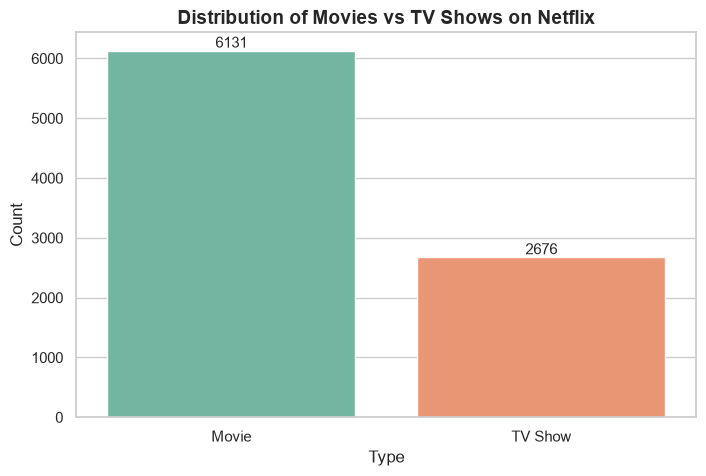

In [19]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='type', data=df, palette='Set2')
plt.title('Distribution of Movies vs TV Shows on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Type', fontsize=12)
plt.ylabel('Count', fontsize=12)

# annotating exact counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11)

plt.show()

### 5.2 Top countries producing content
Identifying the top 10 countries contributing the most content to Netflix.

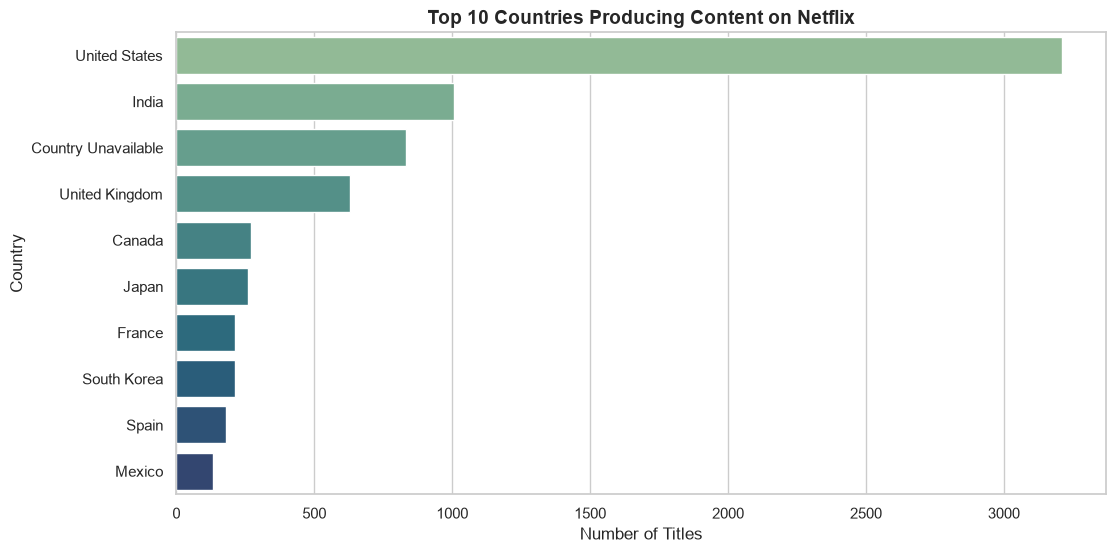

In [20]:
# handling multi country records by extracting the primary country
filtered_countries = df['country'].dropna().apply(lambda x: str(x).split(',')[0]).str.strip()
top_countries = filtered_countries.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='crest')
plt.title('Top 10 Countries Producing Content on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.show()

### 5.3 Content addition trend over years
Analyzing the growth pattern of content added to Netflix over time.

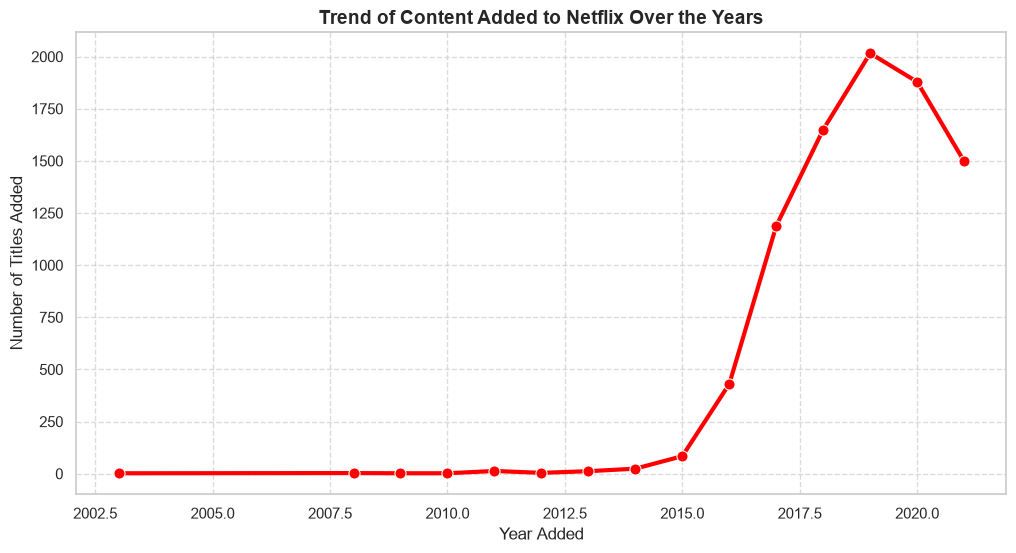

In [21]:
yearly_trend = df['year_added'].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_trend.index, y=yearly_trend.values, marker='o', color='red', linewidth=3, markersize=8)
plt.title('Trend of Content Added to Netflix Over the Years', fontsize=14, fontweight='bold')
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Number of Titles Added', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 5.4 Top movie genres
Exploring the most popular movie genres available on the platform.

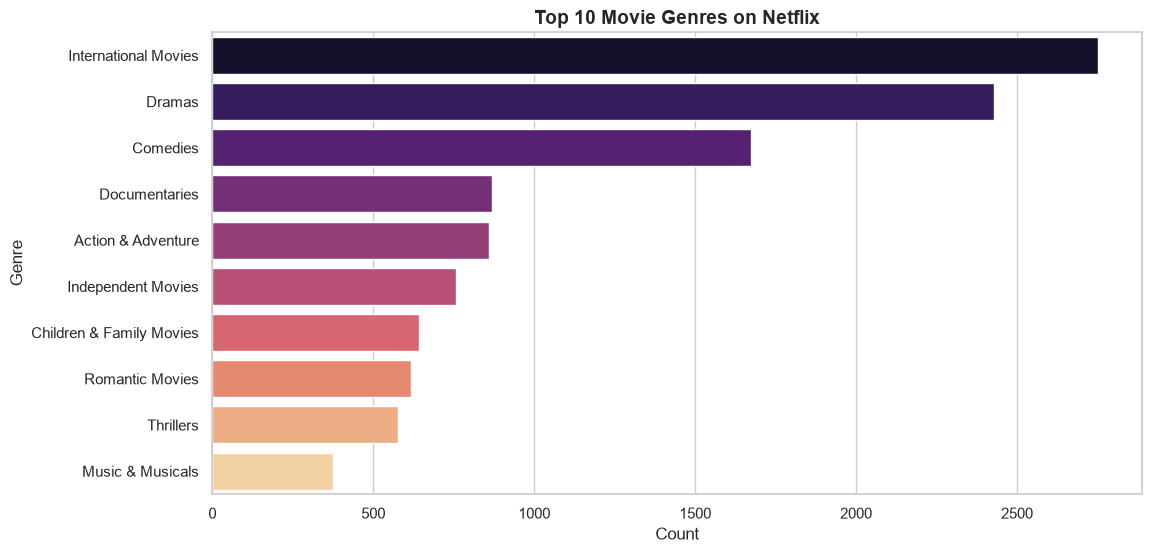

In [22]:
movies_df = df[df['type'] == 'Movie']
genres = movies_df['listed_in'].dropna().apply(lambda x: str(x).split(',')).explode().str.strip()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')
plt.title('Top 10 Movie Genres on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()

##  6. Conclusion & key insights
Summary of findings derived from the analysis:

In [23]:
print("    Netflix EDA Project Insights Summary    ")
print(f"1. Total cleaned records analyzed: {df.shape[0]}")
print(f"2. Content split: Movies dominate the platform significantly compared to TV Shows.")
print(f"3. Top content producing country: {top_countries.index[0]}")
print(f"4. Peak year for additions: {int(yearly_trend.idxmax())}")

    Netflix EDA Project Insights Summary    
1. Total cleaned records analyzed: 8807
2. Content split: Movies dominate the platform significantly compared to TV Shows.
3. Top content producing country: United States
4. Peak year for additions: 2019
